In [1]:
import warnings
warnings.filterwarnings(action='ignore')
import numpy as np
import pandas as pd
from pandas.tseries.offsets import BMonthBegin, BDay
import yfinance as yf
#yf.set_config(proxy='http://46.2.90.210:8080')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.append('C:/Users/11120/Documents/Python/my_packages')
#from utils.performance_measure import *
from my_packages.utils.performance_measure import *

In [2]:
alpha_list = [
    'SMH','IGV','XAR','XBI','XME','XOP','PAVE','ARKK',                        # US industry and theme (8)
    'MGK','MGV','IWM','SCHD','USMV','MTUM','QUAL',                            # US style (7)
    'GDX','URA','IXN','372330.KS','283580.KS','IGF','BOTZ','SKYY','ICLN',     # Global sector and theme (9)
]
start_date = '2000-01-01'

raw = yf.download(alpha_list, start=start_date, auto_adjust=True)['Close']
dataset = raw[alpha_list].resample('B').last().ffill()

[*********************100%***********************]  24 of 24 completed


In [3]:
dataset

Ticker,SMH,IGV,XAR,XBI,XME,XOP,PAVE,ARKK,MGK,MGV,...,QUAL,GDX,URA,IXN,372330.KS,283580.KS,IGF,BOTZ,SKYY,ICLN
Date,,,,,,,,,,,,,,,,,,,,,
2000-05-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05,377.589996,103.629997,260.329987,120.150002,111.059998,127.500000,49.439999,81.339996,412.200012,143.910004,...,201.179993,88.449997,48.630001,106.690002,9115.0,15790.0,61.830002,37.610001,128.570007,17.129999
2026-01-06,387.619995,104.919998,266.130005,122.089996,115.019997,125.540001,49.970001,81.860001,413.309998,145.149994,...,202.910004,92.139999,49.369999,107.660004,9335.0,15995.0,61.700001,37.930000,130.410004,17.200001
2026-01-07,385.019989,106.239998,262.609985,126.430000,114.169998,123.959999,48.970001,81.139999,415.380005,143.520004,...,201.929993,91.059998,49.830002,107.489998,9110.0,15930.0,61.330002,38.160000,131.059998,16.980000


In [4]:
def generate_signal(price, short_window=1, mid_window=3, long_window=12, 
                    short_wgt=1/3, mid_wgt=1/3, long_wgt=1/3):
    price_m = price.resample('BM').last()
    mom_s = (price_m / price_m.shift(short_window))
    mom_s = mom_s.rank(axis=1)
    mom_m = (price_m / price_m.shift(mid_window))
    mom_m = mom_m.rank(axis=1)
    mom_l = (price_m / price_m.shift(long_window))
    mom_l = mom_l.rank(axis=1)
    sig = (mom_s*short_wgt + mom_m*mid_wgt + mom_l*long_wgt).rank(axis=1, ascending=False)
    sig = sig.dropna(thresh=10)
    return sig

def calc_vol(price, ew=False, com=60, window=22):
    ret = price.pct_change()
    if ew==True:
        vol = (ret.ewm(com=com, min_periods=com*2).std()*np.sqrt(260))
    else: 
        vol = (ret.rolling(window).std()*np.sqrt(260))
    return vol

def compute_weight_top_k(price, signal, top_k=5, inverse_vol=False):
    vol = calc_vol(price)
    vol = vol.resample('BM').last()
    wgt    = pd.DataFrame(0., index=signal.index, columns=signal.columns)
    bm_wgt = pd.DataFrame(0., index=signal.index, columns=signal.columns)
    for date in signal.index:
        row = signal.loc[date]
        valid = row[~row.isna()].index
        if len(valid) > 0:
            bm_wgt.loc[date, valid] = 1.0 / len(valid)
        selected = row[row <= top_k].index
        if len(selected) == 0:
            continue
        if inverse_vol:
            inv_vol = 1 / (vol.loc[date, selected])
            inv_vol = inv_vol.replace([np.inf, -np.inf], np.nan).dropna()
            w = inv_vol / inv_vol.sum()
        else:
            w = pd.Series(1.0/len(selected), index=selected)
        wgt.loc[date, selected] = w
    return wgt, bm_wgt

def compute_weight_quantile(price, signal, n_quantiles=5, inverse_vol=False):
    vol = calc_vol(price)
    vol = vol.resample('BM').last()

    bm_wgt = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    q_wgts = {
        f"Q{q}": pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
        for q in range(1, n_quantiles + 1)
    }
    for date in signal.index:
        row = signal.loc[date]
        valid = row[~row.isna()].index
        if len(valid) == 0:
            continue
        bm_wgt.loc[date, valid] = 1.0 / len(valid)
        s = row.loc[valid].copy()
        if s.nunique() == 1:
            continue
        qlabel = pd.qcut(
            s.rank(method="first", ascending=False),
            q=n_quantiles,
            labels=[f"Q{i}" for i in range(1, n_quantiles + 1)]
        )
        for q in qlabel.unique():
            selected = qlabel[qlabel == q].index
            if len(selected) == 0:
                continue

            if inverse_vol:
                inv_vol = 1.0 / vol.loc[date, selected]
                inv_vol = inv_vol.replace([np.inf, -np.inf], np.nan).dropna()
                w = inv_vol / inv_vol.sum()
            else:
                w = pd.Series(1.0 / len(selected), index=selected)
            q_wgts[str(q)].loc[date, selected] = w
    return q_wgts, bm_wgt


In [ ]:
def backtest(price, weight, capital=1000, tcost=0.002, start_date=None):
    if start_date is None:
        start_date = weight.index[0]
        weight_dates = weight.index
    else:
        start_date = weight[start_date:].index[0]
        weight_dates = weight[start_date:].index
    ret = price.pct_change()
    ret_sub = ret[start_date:]
    ret_sub = ret_sub.fillna(0.)
    all_dates = ret_sub.index

    nav = pd.Series(index=all_dates, dtype=float)
    turnover = {}
    nav.loc[start_date] = capital
    dollar_pos = None 
    prev_w = None 
    for i, date in enumerate(all_dates):
        if date in weight_dates:
            if date != start_date:
                prev_date = all_dates[i-1]
                prev_equity = nav.loc[prev_date]
                L_prev = prev_w.sum()
                dollar_pnl = dollar_pos * ret_sub.loc[date].values
                dollar_pos += dollar_pnl
                prev_w = (dollar_pos / dollar_pos.sum()) * L_prev
                new_w = weight.loc[date].values
                turn = np.sum(np.abs(new_w - prev_w)) / 2
                equity_after_cost = (prev_equity + dollar_pnl.sum()) * (1 - turn*tcost*2)
            else:
                new_w = weight.loc[date].values
                turn = np.sum(np.abs(new_w)) / 2
                equity_after_cost = capital  # 첫 시작에서는 거래 비용 차감 안함
                #equity_after_cost = capital * (1 - turn*tcost*2)
            nav.loc[date] = equity_after_cost
            dollar_pos = new_w * equity_after_cost
            turnover[date] = turn
            prev_w = new_w.copy()
        else:
            prev_date = all_dates[i-1]
            prev_equity = nav.loc[prev_date]
            L_prev = prev_w.sum()
            dollar_pnl = dollar_pos * ret_sub.loc[date].values
            dollar_pos += dollar_pnl            
            nav.loc[date] = prev_equity + dollar_pnl.sum()
            prev_w = (dollar_pos / dollar_pos.sum()) * L_prev
    turnover = pd.Series(turnover)
    return nav, turnover

In [6]:
def ts_plot(value, figsize=(12,6)): 
    col = value.columns
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(nrows=1, ncols=1)
    ax = fig.add_subplot(gs[0])
    for i in range(len(col)):
        ax.plot(value[col[i]], label=col[i])
    ax.set_ylabel('(pt)', rotation=0)
    ax.yaxis.set_label_coords(-0.02,1.02)
    ax.legend(loc='upper left')

def allocationChart(weight):
    group_labels = weight.columns
    grouped_df = pd.DataFrame(weight)
    plt.figure(figsize=(8,4))
    plt.stackplot(grouped_df.index, grouped_df.T, labels=group_labels)  
    plt.legend(loc='center left', bbox_to_anchor=(1.02,0.5), ncol=2)
    plt.show()

def holdingCalender(weight):
    tickers = weight.columns
    dates = weight.index
    fig, ax = plt.subplots(figsize=(12,6))
    im = ax.imshow(weight.T, aspect='auto', interpolation=None)
    ax.set_yticks(np.arange(len(tickers)))
    ax.set_yticklabels(tickers)
    # step = max(1, len(dates) // 12)
    step = 12
    xticks = np.arange(0, len(dates), step)
    ax.set_xticks(xticks)
    ax.set_xticklabels([d.strftime('%y.%m') for d in dates[::step]], rotation=45, ha='right')
    ax.set_xlabel('Month')
    ax.set_title('Monthly Holdings')
    for x in range(len(dates)+1):
        ax.axvline(x - 0.5, color='lightgrey', lw=0.3)
    for y in range(len(tickers)+1):
        ax.axhline(y - 0.5, color='lightgrey', lw=0.3)
    plt.tight_layout()
    plt.show()
    

In [72]:
sig = generate_signal(dataset, short_window=4, mid_window=7, long_window=11, short_wgt=0.05, mid_wgt=0.04, long_wgt=0.91)
top_wgt, _ = compute_weight_top_k(dataset, sig, top_k=5, inverse_vol=False)
q_wgts, bm_wgt = compute_weight_quantile(dataset, sig, n_quantiles=5, inverse_vol=False)

In [73]:
bm_wgt.index = bm_wgt.index + BMonthBegin(1)
bm_nav, bm_to = backtest(dataset, bm_wgt, capital=1000, tcost=0.00)
bm_nav.name = 'BM'
bm_to.name = 'BM'

top_wgt.index = top_wgt.index + BMonthBegin(1)
top_nav, top_to = backtest(dataset, top_wgt, capital=1000, tcost=0.00)
top_nav.name = 'top_k'

q_nav = {}
q_to  = {}
for q in range(1, 6):
    wgt = q_wgts[f"Q{q}"]
    wgt.index = wgt.index + BMonthBegin(1)
    nav, turnover = backtest(dataset, wgt, capital=1000, tcost=0.00)
    q_nav[f"Q{q}"] = nav
    q_to[f"Q{q}"]  = turnover
q_nav = pd.DataFrame({k: v for k, v in q_nav.items()})
q_to  = pd.DataFrame({k: v for k, v in q_to.items()})

In [74]:
navs = pd.concat([q_nav,bm_nav], axis=1)
tos  = pd.concat([q_to,bm_to], axis=1)

In [75]:
summary_stats(navs)

,Q1,Q2,Q3,Q4,Q5,BM
nyears,17.117808,17.117808,17.117808,17.117808,17.117808,17.117808
nsamples,4464,4464,4464,4464,4464,4464
cagr,0.044175,0.168747,0.142488,0.158499,0.197976,0.145001
mean,0.079058,0.177166,0.152638,0.167672,0.208437,0.155623
mean-t-stat,1.23651,3.770581,3.509983,3.712149,3.902978,3.404889
vol,0.267205,0.205851,0.196841,0.202107,0.235136,0.200612
skew,-0.262985,-0.005794,-0.159062,-0.479681,-0.384581,-0.369895
kurt,6.123606,8.120219,7.101529,7.98098,4.736151,7.010975
max,0.116581,0.110351,0.121984,0.094516,0.112199,0.097588
min,-0.155512,-0.112364,-0.091012,-0.131951,-0.106899,-0.102228


In [76]:
tos.mean()

Q1    0.202227
Q2    0.468525
Q3    0.572131
Q4    0.508192
Q5    0.256321
BM    0.022700
dtype: float64

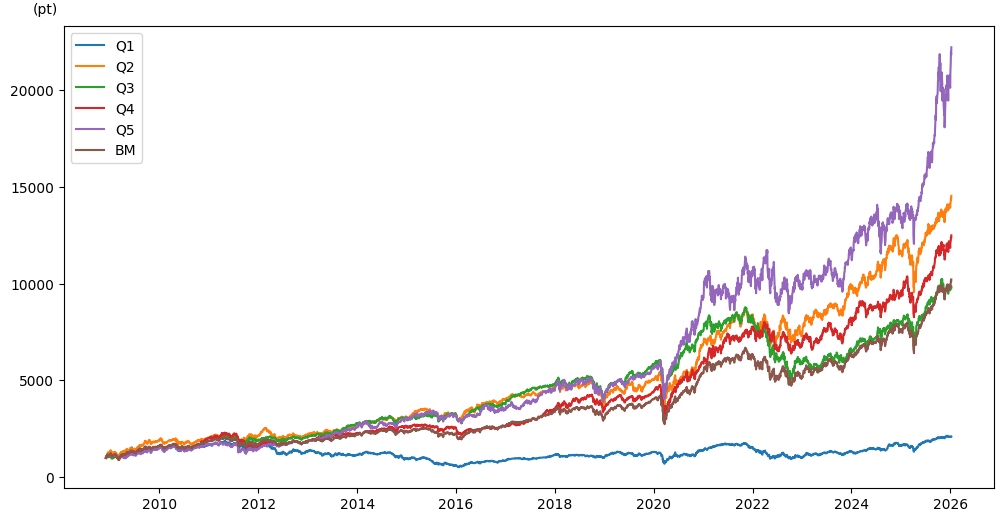

In [66]:
ts_plot(navs)

<Axes: xlabel='Date'>

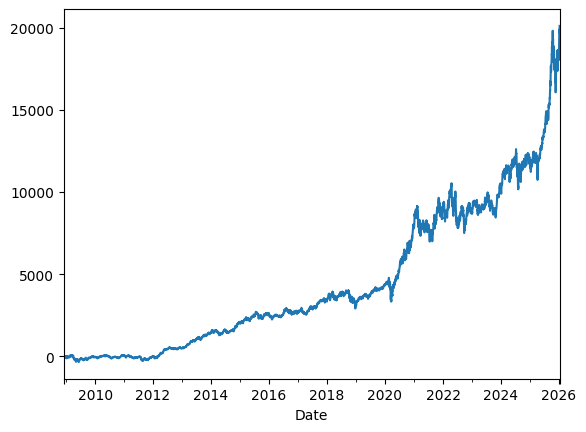

In [52]:
(q_nav['Q5'] - q_nav['Q1']).plot()

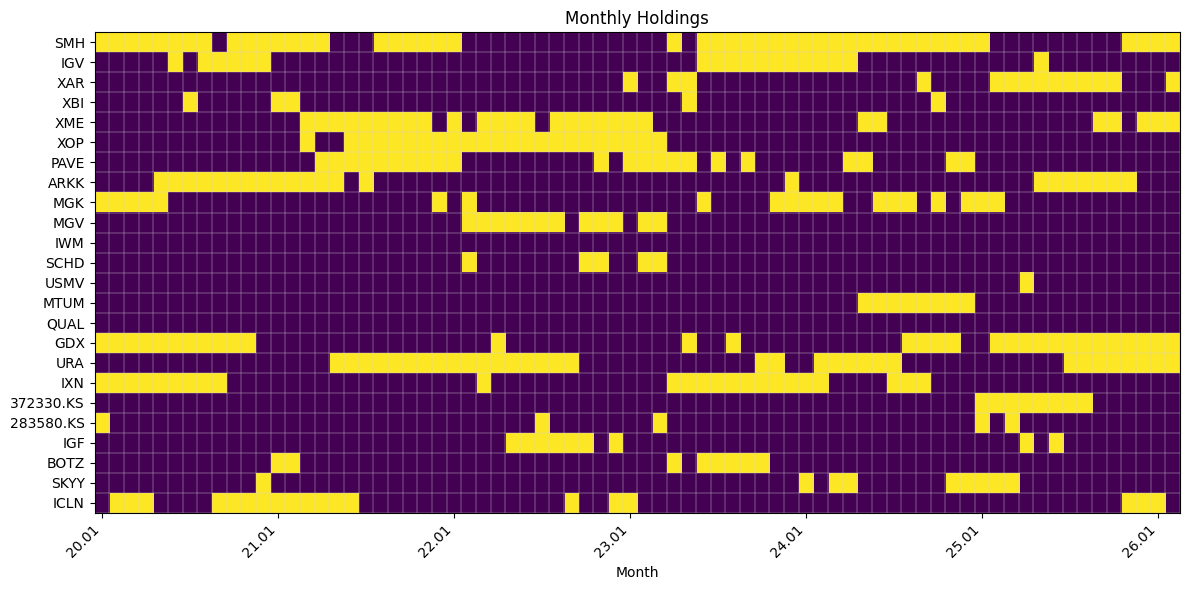

In [80]:
holdingCalender(q_wgts['Q5']['2020':])

In [79]:
sig

Ticker,SMH,IGV,XAR,XBI,XME,XOP,PAVE,ARKK,MGK,MGV,...,QUAL,GDX,URA,IXN,372330.KS,283580.KS,IGF,BOTZ,SKYY,ICLN
Date,,,,,,,,,,,,,,,,,,,,,
2008-11-28,10.0,5.0,NaN,1.0,11.0,6.0,NaN,NaN,3.0,2.0,...,NaN,7.0,NaN,9.0,NaN,NaN,8.0,NaN,NaN,NaN
2008-12-31,9.0,4.0,NaN,1.0,11.0,10.0,NaN,NaN,3.0,5.0,...,NaN,6.0,NaN,8.0,NaN,NaN,7.0,NaN,NaN,NaN
2009-01-30,8.0,2.0,NaN,1.0,11.0,10.0,NaN,NaN,3.0,7.0,...,NaN,5.0,NaN,6.0,NaN,NaN,9.0,NaN,NaN,NaN
2009-02-27,7.0,3.0,NaN,1.0,11.0,10.0,NaN,NaN,4.0,8.0,...,NaN,2.0,NaN,5.0,NaN,NaN,9.0,NaN,NaN,NaN
2009-03-31,6.0,3.0,NaN,1.0,11.0,10.0,NaN,NaN,4.0,8.0,...,NaN,2.0,NaN,5.0,NaN,NaN,9.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-30,7.0,12.0,4.0,23.0,5.0,22.0,16.0,2.0,11.0,20.0,...,19.0,1.0,3.0,8.0,6.0,13.0,15.0,18.0,10.0,14.0
2025-10-31,4.0,17.0,6.0,15.0,7.0,24.0,19.0,3.0,11.0,20.0,...,18.0,1.0,2.0,9.0,8.0,10.0,16.0,14.0,13.0,5.0
2025-11-28,5.0,22.0,7.0,8.0,2.0,24.0,14.0,6.0,13.0,16.0,...,18.0,1.0,3.0,10.0,9.0,15.0,11.0,19.0,21.0,4.0


In [59]:
sig.iloc[-1].sort_values()

Ticker
GDX           1.0
URA           2.0
XME           3.0
SMH           4.0
XAR           5.0
ICLN          6.0
XBI           7.0
ARKK          8.0
IXN           9.0
283580.KS    10.0
PAVE         11.0
MGK          12.0
IWM          13.0
BOTZ         14.0
IGF          15.0
MTUM         16.0
QUAL         17.0
MGV          18.0
SKYY         19.0
IGV          20.0
SCHD         21.0
372330.KS    22.0
USMV         23.0
XOP          24.0
Name: 2026-01-30 00:00:00, dtype: float64

In [376]:
# pip install bayesian-optimization
from bayes_opt import BayesianOptimization

In [ ]:
# Bayesian optimization
def objective(short_window, mid_window, long_window, short_wgt, mid_wgt, long_wgt):
    short_window = int(round(short_window))
    mid_window = int(round(mid_window))
    long_window = int(round(long_window))
    sig = generate_signal(
        dataset, short_window=short_window, mid_window=mid_window, long_window=long_window, 
        short_wgt=short_wgt, mid_wgt=mid_wgt, long_wgt=long_wgt)
    wgt, _ = compute_weight_top_k(dataset, sig, top_k=3)
    wgt.index = wgt.index + BMonthBegin(1)
    alpha_nav, _ = backtest(dataset, wgt, capital=1000, tcost=0.00)
    res = pd.DataFrame(alpha_nav, columns=['alpha'])
    sharpe = summary_stats(res).loc['sharpe'].values[0]
    return sharpe

In [378]:
# Parameter bounds for Bayesian optimization 
pbounds = {
    'short_window': (1, 12),
    'mid_window': (1, 12), 
    'long_window': (1, 12), 
    'short_wgt': (0.001, 1.0),
    'mid_wgt': (0.001, 1.0),
    'long_wgt': (0.001, 1.0),
}

In [379]:
# In-sample optimization 
optimizer = BayesianOptimization(f=objective, pbounds=pbounds, random_state=64)
optimizer.set_gp_params(alpha=1e-5)
optimizer.maximize(init_points=100, n_iter=350)

|   iter    |  target   | short_... | mid_wi... | long_w... | short_wgt |  mid_wgt  | long_wgt  |
-------------------------------------------------------------------------------------------------
| 1         | 0.4142506 | 5.1700837 | 7.2380798 | 7.5515176 | 0.4504090 | 0.4575628 | 0.3123393 |
| 2         | 0.4655582 | 4.4467109 | 4.2434540 | 6.8384970 | 0.3968257 | 0.7190316 | 0.5485439 |
| 3         | 0.4879327 | 7.4028259 | 2.8441603 | 1.3220491 | 0.2095331 | 0.0235528 | 0.6350397 |
| 4         | 0.5865432 | 3.4688591 | 5.3814085 | 7.8145087 | 0.0029465 | 0.0366342 | 0.3774127 |
| 5         | 0.6328410 | 3.3808887 | 5.4533003 | 10.525935 | 0.2564676 | 0.6018334 | 0.2276744 |
| 6         | 0.5508772 | 3.2669674 | 2.9351192 | 10.774592 | 0.6719107 | 0.3764445 | 0.0189699 |
| 7         | 0.4497744 | 4.8779170 | 4.3662503 | 5.6567669 | 0.3947120 | 0.5694445 | 0.5756026 |
| 8         | 0.5278184 | 7.8561108 | 3.7474316 | 2.4404000 | 0.2458280 | 0.9893407 | 0.9570023 |
| 9         | 0.5912

In [369]:
print('best sharpe:', optimizer.max['target'])

best sharpe: 0.8502890335226166


In [ ]:
opt_short_window = int(round(best_params['short_window']))
opt_mid_window = int(round(best_params['mid_window']))
opt_long_window = int(round(best_params['long_window']))
opt_short_wgt = best_params['short_wgt']
opt_mid_wgt = best_params['mid_wgt']
opt_long_wgt = best_params['long_wgt']

s = opt_short_wgt + opt_mid_wgt + opt_long_wgt + 1e-12
opt_short_wgt, opt_mid_wgt, opt_long_wgt = opt_short_wgt/s, opt_mid_wgt/s, opt_long_wgt/s

opt_sig = generate_signal(
    dataset, short_window=opt_short_window, mid_window=opt_mid_window, long_window=opt_long_window, 
    short_wgt=opt_short_wgt, mid_wgt=opt_mid_wgt, long_wgt=opt_long_wgt)
opt_wgt, _ = compute_weight_top_k(dataset, opt_sig, top_k=3)
opt_wgt.index = opt_wgt.index + BMonthBegin(1)
opt_nav, opt_to = backtest(dataset, opt_wgt, capital=1000, tcost=0.00)

In [371]:
opt_short_window, opt_mid_window, opt_long_window

(7, 4, 11)

In [372]:
opt_short_wgt, opt_mid_wgt, opt_long_wgt

(0.02102571093726869, 0.036962976600447436, 0.9420113124610419)

In [ ]:
opt_res = rebase(pd.DataFrame(opt_nav, columns=['OPT']).join(bm_nav), '2001-02-01')

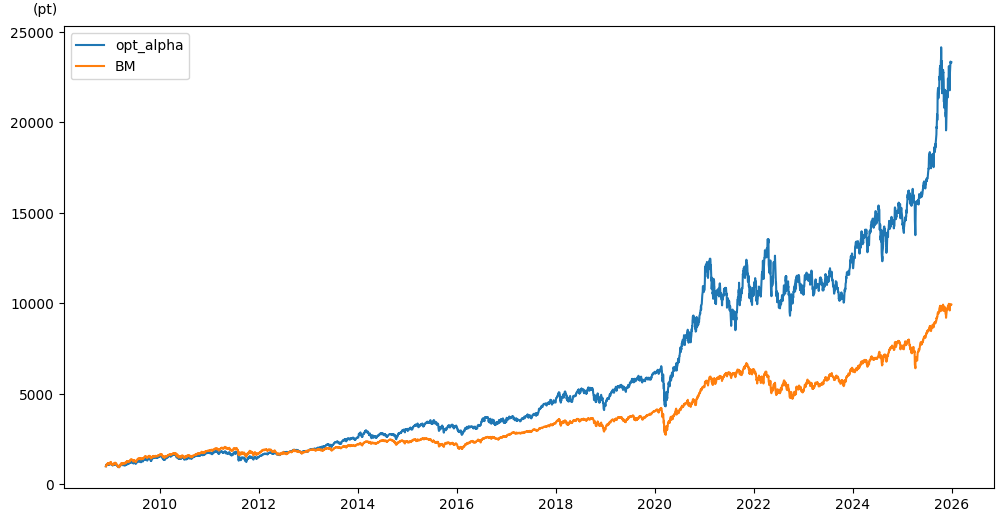

In [374]:
ts_plot(opt_res)

In [375]:
summary_stats(opt_res)

,opt_alpha,BM
nyears,17.087671,17.087671
nsamples,4455,4455
cagr,0.20174,0.143347
mean,0.216997,0.154196
mean-t-stat,3.754767,3.368646
vol,0.256988,0.200704
skew,-0.411704,-0.369562
kurt,4.630479,7.011131
max,0.105869,0.097588
min,-0.135664,-0.102228
